# 01 - Exploratory Data Analysis

**Phase 1 (Weeks 1-2)** of the Portuguese wildfire catastrophe loss model.

This notebook loads a real per-fire wildfire database for Portugal and
explores the resulting frequency and severity patterns.

See `docs/phase1-plan.md` and `docs/worklog.md` in the repo root for the
full data-sourcing story. In short:

- The primary data source is EFFIS's own Rapid Damage Assessment (MODIS-
  based) fire database, obtained via EFFIS's official Data Request Form
  (a one-time manual submission, since EFFIS's live Statistics Portal has
  no public JSON API). This gives real per-fire dates, real NUTS2 region
  locations, and real burned areas for Portugal, 2010-2024.
- The MODIS-era product maps fires of roughly 30 ha or larger (per EFFIS's
  own documentation), an estimated 75-80% of total burnt area despite being
  a minority of total fire count. From 2019 the export switches to
  Sentinel-2 and includes fires down to 1 ha, so **a "fire event" in this
  model means a mapped fire of at least 30 ha, applied explicitly and
  uniformly to every year** (`MIN_FIRE_AREA_HA`), not every ignition and not
  whatever each sensor happened to map - see "Why the size threshold is
  applied explicitly" below.
- No public source publishes verified EUR loss per individual fire. A
  documented EUR/ha calibration constant (derived from published ICNF/OECD
  aggregate figures) is applied to real burned areas instead.
- Live OWID/GWIS annual aggregates are still fetched, but only as an
  independent cross-check against the real per-fire data, not as a
  modeling input. See "Data gaps and assumptions" below for what that
  cross-check found.

## Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import requests

from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY = "Portugal"
MAX_YEAR = 2024  # freeze scope to the PRD window; excludes the still-in-progress current season
# EFFIS mapped fires below this size are not comparable across the whole window: the
# mapping source changes from MODIS (2010-2018, ~20 ha minimum) to Sentinel-2 (2020-2024,
# down to 1 ha), so raw counts are not a stationary series. Applied uniformly to every year.
MIN_FIRE_AREA_HA = 30


## Data loading

`load_effis_fire_database` reads the real, committed per-fire snapshot
(the primary data source). `fetch_annual_fire_counts` and
`fetch_annual_burnt_area` pull live OWID/GWIS aggregates used only for
cross-validation further down, not as modeling inputs.

In [2]:
def load_effis_fire_database(path: Path = RAW_DIR / "effis_fire_database_pt_2010_2024.csv",
                             min_area_ha: float = MIN_FIRE_AREA_HA) -> pd.DataFrame:
    """Load the real per-fire EFFIS Rapid Damage Assessment database for Portugal.

    Source: EFFIS's official Data Request Form (forest-fire.emergency.
    copernicus.eu/apps/data.request.form/), dataset "Burnt area mapped
    using Sentinel2/MODIS images", Portugal, 2010-01-01 to 2024-12-31.
    Obtained as a one-time manual submission (not a live API), so this
    file is a static, committed snapshot rather than something re-fetched
    on each run - no reproducibility drift risk for this component.

    Per EFFIS's own documentation (see the accompanying .readme.txt in
    data/raw/), this product maps fires of roughly 30 ha or larger, which
    still represents an estimated 75-80% of Portugal's total burnt area
    despite being a minority of total fire count. That only holds for the
    MODIS-era records (2010-2018): from 2019 the export's `map_source`
    switches to Sentinel-2 and records as small as 1 ha appear (62-82% of
    2020-2024 rows are under 30 ha), which would make annual counts ~3x
    higher for a sensor reason, not a hazard reason. Three cleaning steps
    are therefore applied: ~40 of 6,608 raw records with area_ha <= 0 are dropped as
    non-physical mapping artifacts (EFFIS's own caveats about small/
    unmapped islands within a burn scar), and 69 exact duplicate records
    (same parish, area, and timestamp logged under a different id, ~104 ha
    total, concentrated in 2021-2024) are deduplicated as a confirmed
    export artifact - see docs/worklog.md for how this was found. Finally,
    only fires of at least `min_area_ha` are kept (default
    MIN_FIRE_AREA_HA = 30), so frequency and severity are defined on the
    same size threshold in every year.

    Parameters
    ----------
    path : Path
        Location of the committed raw EFFIS export.
    min_area_ha : float
        Minimum burned area for a record to count as a fire event.

    Returns
    -------
    pd.DataFrame
        Columns: Date, Location, Burned_Area_ha - one row per real mapped
        fire event, sorted by date.
    """
    df = pd.read_csv(path, encoding="utf-8")
    df["Date"] = pd.to_datetime(df["initialdate"], format="mixed")
    df = df[df["area_ha"] > 0]
    df = df.drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"], keep="first")
    df = df[df["area_ha"] >= min_area_ha]

    result = df.rename(columns={"admlvl2": "Location", "area_ha": "Burned_Area_ha"})
    return result[["Date", "Location", "Burned_Area_ha"]].sort_values("Date").reset_index(drop=True)

### Why the size threshold is applied explicitly

The export's mapping source changes over time, and the smallest mapped fire
changes with it. The table below is computed from the raw file before any
size filter.


In [3]:
raw = pd.read_csv(RAW_DIR / "effis_fire_database_pt_2010_2024.csv", encoding="utf-8")
raw["year"] = pd.to_datetime(raw["initialdate"], format="mixed").dt.year
raw = raw[raw["area_ha"] > 0].drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"])

mapping_break = raw.groupby("year").agg(
    map_source=("map_source", lambda s: "/".join(sorted(s.unique()))),
    records=("area_ha", "size"),
    min_area_ha=("area_ha", "min"),
    pct_under_threshold=("area_ha", lambda a: (a < MIN_FIRE_AREA_HA).mean() * 100),
).round(1)
print(mapping_break)

before = raw.groupby("year").size()
after = raw[raw["area_ha"] >= MIN_FIRE_AREA_HA].groupby("year").size()
print()
print(f"Mean records/year, unfiltered:   2010-2019 {before.loc[:2019].mean():.0f}   2020-2024 {before.loc[2020:].mean():.0f}")
print(f"Mean records/year, >= {MIN_FIRE_AREA_HA} ha:      2010-2019 {after.loc[:2019].mean():.0f}   2020-2024 {after.loc[2020:].mean():.0f}")


           map_source  records  min_area_ha  pct_under_threshold
year                                                            
2010            modis      307           20                  4.9
2011            modis      319           20                  5.0
2012            modis      239           15                  5.0
2013            modis      359           12                  9.2
2014            modis       35           24                  2.9
2015            modis      177           16                  4.5
2016            modis      322           19                  3.1
2017            modis      414           22                  1.4
2018            modis       86           20                  9.3
2019  modis/sentinel2      222           21                 22.5
2020        sentinel2      465            1                 62.4
2021        sentinel2      748            1                 75.0
2022        sentinel2     1210            1                 78.7
2023        sentinel2    

In [4]:
def fetch_annual_fire_counts(country: str = COUNTRY,
                              save_path: Path = RAW_DIR / "effis_annual_fire_counts.csv") -> pd.DataFrame:
    """Fetch annual wildfire counts for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS (Global Wildfire Information
    System, JRC/Copernicus) annual fire-count series, VIIRS/MODIS-detection
    based and covering *all* fire sizes. Not used as the model's frequency
    source (see load_effis_fire_database) - kept only to cross-check
    against the real large-fire-only counts, since the two series measure
    different things and are not expected to reconcile (see "Data gaps and
    assumptions").

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, fire_count (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-number-of-fires.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Annual number of fires": "fire_count"}
    )
    return df[["year", "fire_count"]].sort_values("year").reset_index(drop=True)

In [5]:
def fetch_annual_burnt_area(country: str = COUNTRY,
                             save_path: Path = RAW_DIR / "gwis_annual_burnt_area.csv") -> pd.DataFrame:
    """Fetch annual burnt area (hectares) for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS's MODIS-derived annual
    burnt-area-by-region series, covering *all* fire sizes. Used below to
    check what share of total burnt area the real large-fire-only dataset
    captures, not as a modeling input.

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, burnt_area_ha (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-area-burnt-by-wildfires-gwis.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Yearly burned area across all land types": "burnt_area_ha"}
    )
    return df[["year", "burnt_area_ha"]].sort_values("year").reset_index(drop=True)

In [6]:
def build_loss_calibration(save_path: Path = RAW_DIR / "annual_loss_calibration.csv") -> pd.DataFrame:
    """Build (and persist) the EUR/ha loss calibration reference table.

    No public source publishes verified EUR loss per individual fire.
    Figures below are period/annual aggregates from published reports,
    used to derive documented EUR/ha calibration constants.

    Sources:
    - Long-run average: ICNF-derived cumulative figures for 1975-2021
      (~5.2M ha burnt, >EUR 10bn in losses) imply ~EUR 1,923/ha.
    - 2017 (catastrophic year): ~EUR 1.5bn total losses (June + October
      fires) against 523,552 ha burnt that year (OWID/GWIS) implies
      ~EUR 2,865/ha - notably above the long-run average, reflecting a
      wildland-urban-interface year with high fatality and
      structure-loss shares relative to area burned.

    Returns
    -------
    pd.DataFrame
        Columns: label, eur_per_ha, source.
    """
    calibration = pd.DataFrame([
        {
            "label": "long_run_1975_2021",
            "eur_per_ha": 10_000_000_000 / 5_200_000,
            "source": "ICNF cumulative 1975-2021 burnt area & losses, via OECD/press reporting",
        },
        {
            "label": "catastrophic_2017",
            "eur_per_ha": 1_500_000_000 / 523_552,
            "source": "2017 fire season total losses vs. 2017 burnt area (October 2017 Iberian wildfires)",
        },
    ])
    save_path.write_text(calibration.to_csv(index=False), encoding="utf-8")
    return calibration

## Plotting functions

In [7]:
def plot_annual_fire_counts(df: pd.DataFrame, date_col: str = "Date", ax=None):
    """Plot a bar chart of fire occurrence counts by year.

    Parameters
    ----------
    df : pd.DataFrame
        Fire occurrence data with a date column.
    date_col : str
        Name of the column containing event dates.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    counts = df[date_col].dt.year.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fire count")
    ax.set_title("Annual fire occurrence counts")
    return ax

In [8]:
def plot_loss_histogram(df: pd.DataFrame, loss_col: str = "Estimated_Loss_EUR", bins: int = 50, ax=None):
    """Plot a histogram of per-event loss magnitude.

    Parameters
    ----------
    df : pd.DataFrame
        Loss data with a numeric loss column.
    loss_col : str
        Name of the column containing loss amounts.
    bins : int
        Number of histogram bins.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(df[loss_col], bins=bins)
    ax.set_xlabel("Estimated loss (EUR)")
    ax.set_ylabel("Frequency")
    ax.set_title("Loss magnitude distribution")
    return ax

In [9]:
def plot_empirical_cdf(data: np.ndarray, ax=None, label: str = "Empirical"):
    """Plot the empirical CDF of a 1D numeric array.

    Parameters
    ----------
    data : np.ndarray
        Sample values (e.g. per-event losses or annual counts).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    label : str
        Legend label for this CDF curve.
    """
    if ax is None:
        _, ax = plt.subplots()
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label)
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    return ax

## Run EDA

In [10]:
processed_df = load_effis_fire_database()
calibration_df = build_loss_calibration()

eur_per_ha = calibration_df.loc[calibration_df["label"] == "long_run_1975_2021", "eur_per_ha"].iloc[0]
processed_df["Estimated_Loss_EUR"] = processed_df["Burned_Area_ha"] * eur_per_ha
processed_df.to_csv(PROCESSED_DIR / "wildfires_processed.csv", index=False)

print(f"Years covered: {processed_df['Date'].dt.year.min()}-{processed_df['Date'].dt.year.max()}")
print(f"Total real fire events: {len(processed_df)}")
print(f"Calibration constant used: EUR {eur_per_ha:,.0f} / ha")
print(f"NaN check: {processed_df.isna().sum().sum()} missing values")
processed_df.head()

Years covered: 2010-2024
Total real fire events: 3291
Calibration constant used: EUR 1,923 / ha
NaN check: 0 missing values


,Date,Location,Burned_Area_ha,Estimated_Loss_EUR
0,2010-03-13,Norte,73,1.403846e+05
1,2010-04-10,Norte,288,5.538462e+05
2,2010-04-14,Norte,289,5.557692e+05
3,2010-05-04,Norte,530,1.019231e+06
4,2010-05-05,Norte,53,1.019231e+05


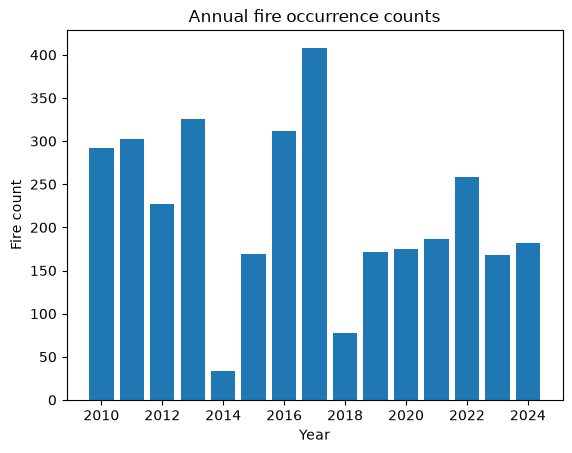

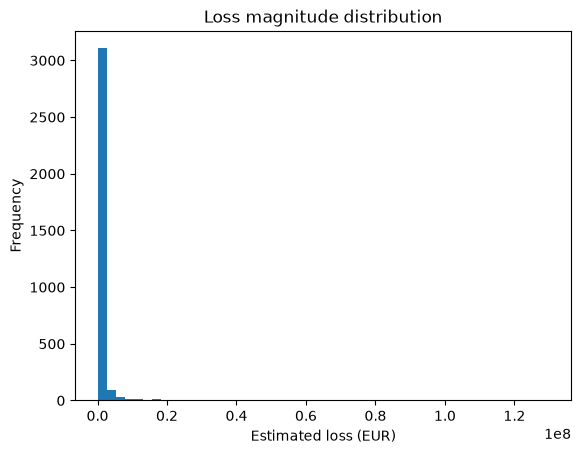

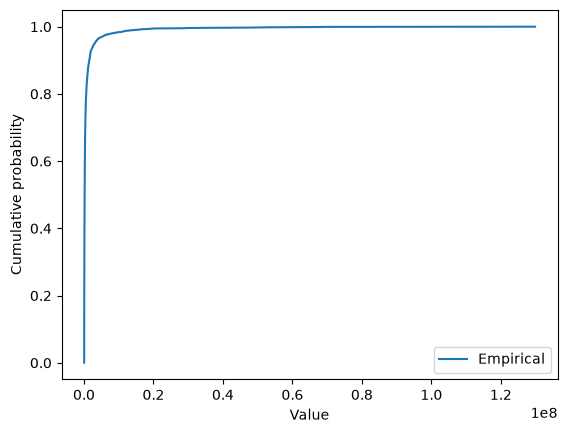

In [11]:
plot_annual_fire_counts(processed_df)
plt.show()

plot_loss_histogram(processed_df)
plt.show()

plot_empirical_cdf(processed_df["Estimated_Loss_EUR"].values)
plt.show()

## Cross-validation against independent aggregate sources

Compares the real large-fire dataset against live OWID/GWIS annual
aggregates (all fire sizes), as an independent sanity check rather than a
reconciliation - the two sources measure different things (see "Data gaps
and assumptions").

In [12]:
owid_counts = fetch_annual_fire_counts()
owid_counts = owid_counts[owid_counts["year"] <= MAX_YEAR]
gwis_area = fetch_annual_burnt_area()
gwis_area = gwis_area[gwis_area["year"] <= MAX_YEAR]

real_annual = processed_df.groupby(processed_df["Date"].dt.year).agg(
    real_large_fire_count=("Burned_Area_ha", "size"),
    real_large_fire_area_ha=("Burned_Area_ha", "sum"),
)
real_annual.index.name = "year"

comparison = real_annual.join(owid_counts.set_index("year")).join(gwis_area.set_index("year"))
comparison["large_fire_vs_gwis_ratio_pct"] = (
    comparison["real_large_fire_area_ha"] / comparison["burnt_area_ha"] * 100
)
print(comparison)
print()

def area_ratio(frame):
    return frame["real_large_fire_area_ha"].sum() / frame["burnt_area_ha"].sum() * 100

total_ratio = area_ratio(comparison)
early_ratio = area_ratio(comparison.loc[:2019])
recent_ratio = area_ratio(comparison.loc[2020:])
n_count_exceed = int((comparison["real_large_fire_count"] > comparison["fire_count"]).sum())
n_count_years = int(comparison["fire_count"].notna().sum())

print(f"Total-to-total area ratio, all years (properly weighted): {total_ratio:.1f}%")
print(f"  2010-2019: {early_ratio:.1f}%    2020-2024: {recent_ratio:.1f}%")
print("A simple mean of per-year ratios would overstate the disagreement, since it weights")
print("small years (e.g. 2021) the same as large ones (e.g. 2017).")
print()
print(f"Years where the >= {MIN_FIRE_AREA_HA} ha count exceeds OWID's all-fire count: {n_count_exceed} of {n_count_years}")
print()

rolling = comparison[["real_large_fire_area_ha", "burnt_area_ha"]].rolling(3).sum().dropna()
rolling["ratio_3yr_pct"] = rolling["real_large_fire_area_ha"] / rolling["burnt_area_ha"] * 100
print("3-year rolling ratio (smooths out single-year noise):")
print(rolling["ratio_3yr_pct"].round(0).astype(int))


      real_large_fire_count  real_large_fire_area_ha  fire_count  \
year                                                               
2010                    292                   127560         NaN   
2011                    303                    64442         NaN   
2012                    227                   101053       815.0   
2013                    326                   153408      1143.0   
2014                     34                    11550       175.0   
2015                    169                    47286       600.0   
2016                    312                   165853       975.0   
2017                    408                   563530      1365.0   
2018                     78                    37144       209.0   
2019                    172                    33451       359.0   
2020                    175                    62557       323.0   
2021                    187                    25855       284.0   
2022                    258                   10

## Domain validation: order-of-magnitude sanity check

Per the PRD's Domain Validation criterion, checked here early rather than
waiting for Phase 4: does the modeled annual loss land in the right ballpark
for well-documented years? Now on real per-fire data, this is a genuine
test of the calibration constant, not just the synthesis method.

In [13]:
annual_modeled_loss = processed_df.groupby(processed_df["Date"].dt.year)["Estimated_Loss_EUR"].sum()
print(annual_modeled_loss.map(lambda x: f"EUR {x:,.0f}"))

# Published benchmarks (sourced, see data/raw/published_loss_benchmarks.csv)
bench = pd.read_csv(RAW_DIR / "published_loss_benchmarks.csv").set_index("measure")
modeled_2024 = annual_modeled_loss.loc[2024]
model_area_2024 = processed_df.loc[processed_df["Date"].dt.year == 2024, "Burned_Area_ha"].sum()
agif_area = bench.loc["burnt_area_agif", "value"]
forest = bench.loc["forest_sector_loss", "value"]
insured = bench.loc["insured_claims_provisional", "value"]

print()
print("2024 area check (independent of the EUR calibration):")
print(f"  EFFIS >= {MIN_FIRE_AREA_HA} ha: {model_area_2024:,.0f} ha  vs  AGIF national: {agif_area:,.0f} ha  ({model_area_2024 / agif_area:.1%})")
print()
print("2024 loss comparison (modeled total vs the only euro figures found):")
print(f"  Modeled total, EUR {eur_per_ha:,.0f}/ha:            EUR {modeled_2024 / 1e6:,.0f}m")
print(f"  Forest-sector loss only (AGIF):         EUR {forest / 1e6:,.0f}m  = {forest / modeled_2024:.0%} of modeled; implies EUR {forest / agif_area:,.0f}/ha")
print(f"  + insured claims, Sep fires (APS):      EUR {(forest + insured) / 1e6:,.0f}m  = {(forest + insured) / modeled_2024:.0%} of modeled")
print("  These are components of loss, not a total: they exclude uninsured homes and businesses,")
print("  agriculture, public infrastructure and firefighting cost. No published TOTAL economic loss")
print("  for 2023 or 2024 was found, so the PRD's 'within ~20% of published reports' test cannot")
print("  be run for those years. The modeled figure is above the measured floor, as it should be,")
print("  but that is a bracket, not a validation.")
print()
print("Other reference points:")
print("  2017: ~EUR 1.5bn total (June + October fires), press/government reporting. Modeled vs this is")
print("  not independent - the gap is the 1,923 vs 2,865 EUR/ha calibration gap restated.")
print("  2022 Serra da Estrela fire (EMSR618): ~25,000 ha; 2024 Central Madeira fire (EMSR748): >5,000 ha")
print("  (both from earlier research, not re-verified in this pass).")
print(f"  Copernicus EMS, Sept 2024 mainland fires: {bench.loc['ems_burnt_area_all_activations', 'value']:,.1f} ha across 4 areas of interest;")
print(f"  EMSR760 (Sever do Vouga) alone: {bench.loc['ems_emsr760_burnt_area', 'value']:,.1f} ha.")
top2024 = processed_df[processed_df["Date"].dt.year == 2024].nlargest(1, "Burned_Area_ha").iloc[0]
print(f"  Largest 2024 record here: {top2024['Burned_Area_ha']:,.0f} ha ({top2024['Location']}, {top2024['Date']:%Y-%m-%d}).")
print("  That exceeds EMSR760's 21,262 ha, so it cannot be that activation's perimeter as-is; it may merge")
print("  adjacent fires or be a different fire. Not confirmed either way.")


Date
2010      EUR 245,307,692
2011      EUR 123,926,923
2012      EUR 194,332,692
2013      EUR 295,015,385
2014       EUR 22,211,538
2015       EUR 90,934,615
2016      EUR 318,948,077
2017    EUR 1,083,711,538
2018       EUR 71,430,769
2019       EUR 64,328,846
2020      EUR 120,301,923
2021       EUR 49,721,154
2022      EUR 200,728,846
2023       EUR 70,875,000
2024      EUR 276,315,385
Name: Estimated_Loss_EUR, dtype: str

2024 area check (independent of the EUR calibration):
  EFFIS >= 30 ha: 143,684 ha  vs  AGIF national: 137,667 ha  (104.4%)

2024 loss comparison (modeled total vs the only euro figures found):
  Modeled total, EUR 1,923/ha:            EUR 276m
  Forest-sector loss only (AGIF):         EUR 67m  = 24% of modeled; implies EUR 487/ha
  + insured claims, Sep fires (APS):      EUR 84m  = 30% of modeled
  These are components of loss, not a total: they exclude uninsured homes and businesses,
  agriculture, public infrastructure and firefighting cost. No published TOT

## Data gaps and assumptions

**Frequency and severity data (real, per-fire):**
- Source: EFFIS's Rapid Damage Assessment (MODIS-based) fire database,
  obtained via EFFIS's official Data Request Form as a one-time manual
  submission for Portugal, 2010-01-01 to 2024-12-31. This is a static
  file committed to `data/raw/`, not a live API - no reproducibility
  drift risk for this component.
- **Scope: a mapped fire of at least 30 ha, applied explicitly.** EFFIS's
  documentation says the MODIS product maps fires of roughly 30 ha or
  larger (an estimated 75-80% of burnt area). That holds for 2010-2018, but
  the export's `map_source` becomes `modis/sentinel2` in 2019 and
  `sentinel2` from 2020, and the smallest mapped fire drops from ~12-24 ha
  to 1 ha: 62-82% of 2020-2024 rows are under 30 ha versus 1-9% in
  2010-2018. Unfiltered, mean annual counts jump from ~248 (2010-2019) to
  ~811 (2020-2024) for a sensor reason, not a hazard reason. An explicit
  `MIN_FIRE_AREA_HA = 30` filter is therefore applied to every year, which
  leaves 3,291 events, keeps 98.2% of mapped area, and gives 232 vs 194
  mean events/year for 2010-2019 vs 2020-2024, i.e. no upward trend in
  counts. This is a deliberate scope choice for a tail-risk model, and it
  keeps frequency and severity defined on one consistent threshold.
- 40 of 6,608 raw records had `area_ha <= 0` and were dropped as
  non-physical mapping artifacts (EFFIS's own notes mention small/
  unmapped islands within a burn scar as a known source of this).
- 69 further records were exact duplicates (same parish, area, and
  timestamp logged under a different `id`), all tiny fires (1-12 ha)
  concentrated in 2021-2024. Confirmed as a real export artifact and
  deduplicated; immaterial in area (~104 ha) and now also removed by the
  size threshold, but kept as an explicit step since it was a genuine
  defect. Of the 6,533 records after cleaning, 3,242 fall below 30 ha.
- **Count discrepancy vs OWID: resolved.** An earlier pass found EFFIS
  large-fire counts *exceeding* OWID's all-fire counts (e.g. 2022: 1,210
  vs 465) and attributed it to MODIS-polygon vs VIIRS-detection
  methodology. The real cause was the unfiltered Sentinel-2 records
  described above: with the 30 ha filter the EFFIS count is below OWID's
  in every year with OWID data (see the cross-validation cell).
- **Area discrepancy vs GWIS: narrowed, not closed.** An earlier "mean
  ratio" of 116.6% was itself misleading (an unweighted mean over-weights
  small years); the weighted total-to-total ratio is 106.1% unfiltered,
  104.2% with the 30 ha filter. Split by period, the filter leaves 2010-2019
  at ~102% but only brings 2020-2024 from ~120% down to ~112%: the
  sub-30 ha fires explain part of the recent-years excess, not all of it.
  The remainder is not explained (not the duplicate records; candidate
  causes not yet checked are GWIS's most recent years being less finalized,
  and Sentinel-2 10 m perimeters delineating burn scars differently from
  250 m MODIS). A ~12% overshoot in 2020-2024 is small enough not to change
  the model's conclusions, and is left as a documented open question.
- **Frequency is strongly overdispersed.** Annual counts range from 34 (2014)
  to 408 (2017) around a mean of ~219, a variance-to-mean ratio of ~44
  where a Poisson process would give ~1. Phase 2 should expect a plain
  Poisson to fail goodness-of-fit and compare a Negative Binomial.
- `Location` is the real NUTS2-level region (EFFIS's `admlvl2` field).
  Finer `admlvl3`/`admlvl5` fields exist in the raw file but are
  intentionally unused, matching the PRD's explicit exclusion of
  sub-regional/spatial granularity from scope.

**Loss calibration (EUR/ha):**
- No source publishes verified EUR loss per individual fire. A single
  documented calibration constant (long-run 1975-2021 ICNF-derived
  average, ~EUR 1,923/ha) is applied uniformly to every real fire's
  burnt area. **This means modeled loss is burnt area times a constant**:
  the loss distribution has exactly the shape of the area distribution,
  and VaR/ES in euros are the area VaR/ES rescaled. That is acceptable for
  this scope but should be read as a burnt-area model with a euro scale.
- The constant comes from all-fire area totals (~5.2M ha over 1975-2021),
  while this dataset covers 30 ha+ fires, so the two bases differ slightly.
- **Known limitation**: real losses are not strictly linear in burnt
  area - a catastrophic wildland-urban-interface fire (e.g. 2017, at an
  implied ~EUR 2,865/ha) carries far higher losses per hectare than a
  remote forest fire, because fatalities and structure loss dominate,
  not hectares burned. Flagged as a named limitation for the Phase 4/5
  write-up, not hidden in the numbers.
- **External check, and what it can and cannot show.** 2024 burnt area
  agrees with AGIF's national figure (143,684 ha vs 137,667 ha, +4%). For
  loss, the only published euro figures found are components: forest-sector
  loss of EUR 67m (forest only, excluding homes and infrastructure) and
  provisional insured claims above EUR 17m for the September fires. Together
  ~EUR 84m, against a modeled 2024 total of ~EUR 276m: the model sits above
  the measured floor, as a total should, but no published total economic loss
  for 2023 or 2024 was found, so this brackets the calibration rather than
  validating it. The 2017 comparison (EUR 1.08bn modeled vs ~EUR 1.5bn
  reported) is not independent, since both derive from the same 2017
  calibration gap. The PRD's "within ~20% of published reports" criterion
  needs a defined benchmark before Phase 4.

**Superseded approach**: an earlier version of this notebook synthesized
individual fire records to match real annual aggregates, since the real
per-fire database hadn't arrived yet. That synthesis step has been fully
replaced now that real data is available - see `docs/worklog.md` for that
history.